# 1D CNN with SincNet for ECG Classification

Notebook ini berisi implementasi lengkap 1D CNN menggunakan SincNet layer untuk klasifikasi data ECG.

## Pipeline:
1. **Import Libraries & Setup**
2. **Model Architecture (SincNet)**
3. **Data Preparation**
4. **Training**
5. **Evaluation & Metrics**
6. **Visualization**

## 1. Import Libraries & Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

import math
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Set device
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

# Set plot style
plt.style.use('default')
sns.set_palette("husl")

Using device: mps


## 2. Model Architecture - SincNet

In [ ]:
class SincConv1d(nn.Module):
    def __init__(self, out_channels, kernel_size, sample_rate=200):
        super().__init__()
        self.out_channels = out_channels
        self.kernel_size  = kernel_size
        self.sample_rate  = sample_rate
        self.min_freq, self.max_freq = 0.5, sample_rate/2 - 1
        low_hz  = np.linspace(self.min_freq, 30, out_channels)
        high_hz = low_hz + 5
        self.low_hz_  = nn.Parameter(torch.Tensor(low_hz))
        self.band_hz_ = nn.Parameter(torch.Tensor(high_hz - low_hz))
        n = torch.arange(-(kernel_size//2), (kernel_size//2) + 1)
        self.register_buffer("n", n)
    def forward(self, x):
        low  = self.min_freq + torch.abs(self.low_hz_)
        high = torch.clamp(low + torch.abs(self.band_hz_), self.min_freq, self.max_freq)
        band = (high - low)[:, None]
        f_t_low  = 2*math.pi*low[:,None]*self.n/self.sample_rate
        f_t_high = 2*math.pi*high[:,None]*self.n/self.sample_rate
        filters = (torch.sin(f_t_high) - torch.sin(f_t_low)) / (self.n/self.sample_rate + 1e-8)
        filters = filters / (2*band)
        filters = filters * torch.hamming_window(self.kernel_size+1).to(x.device)
        filters = filters.unsqueeze(1)
        return F.conv1d(x, filters, stride=1, padding=self.kernel_size//2)

class SincNetDemo(nn.Module):
    def __init__(self, sample_rate=200):
        super().__init__()
        self.sinc = SincConv1d(8, 252, sample_rate)
        self.pool = nn.MaxPool1d(4)
        self.conv = nn.Conv1d(8, 32, 5)
        self.gap  = nn.AdaptiveAvgPool1d(1)
        self.fc   = nn.Linear(32, 2)
    def forward(self, x):
        x = torch.relu(self.pool(self.sinc(x)))
        x = torch.relu(self.conv(x))
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

# Create model instance
model = SincNetDemo(sample_rate=200).to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

SincNetDemo(
  (sinc): SincConv1d()
  (pool): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (conv): Conv1d(16, 32, kernel_size=(5,), stride=(1,))
  (gap): AdaptiveAvgPool1d(output_size=1)
  (fc): Linear(in_features=32, out_features=2, bias=True)
)

Total parameters: 2,690


## 3. Data Preparation

In [3]:
class ECGDataset(Dataset):
    """
    Custom Dataset for ECG data
    """
    def __init__(self, data_dir='segmented_npy'):
        self.data_dir = data_dir
        self.file_list = [f for f in os.listdir(data_dir) if f.endswith('.npy')]
        
        print(f"Found {len(self.file_list)} files in {data_dir}")
        
    def __len__(self):
        return len(self.file_list)
    
    def __getitem__(self, idx):
        filename = self.file_list[idx]
        filepath = os.path.join(self.data_dir, filename)
        
        # Load data
        data = np.load(filepath)
        
        # Extract label from filename (e.g., s1_0001_label0.npy -> label 0)
        label = int(filename.split('_label')[-1].split('.')[0])
        
        # Convert to tensor and add channel dimension
        data = torch.FloatTensor(data).unsqueeze(0)  # Shape: (1, length)
        label = torch.LongTensor([label])[0]
        
        return data, label

# Create dataset
dataset = ECGDataset('segmented_npy')
print(f"Dataset size: {len(dataset)}")

# Check data shape
sample_data, sample_label = dataset[0]
print(f"Sample data shape: {sample_data.shape}")
print(f"Sample label: {sample_label}")

# Count labels
labels = []
for i in range(len(dataset)):
    _, label = dataset[i]
    labels.append(label.item())

unique, counts = np.unique(labels, return_counts=True)
print(f"\nLabel distribution:")
for u, c in zip(unique, counts):
    print(f"  Label {u}: {c} samples ({c/len(labels)*100:.1f}%)")

Found 80493 files in segmented_npy
Dataset size: 80493
Sample data shape: torch.Size([1, 27000])
Sample label: 0

Label distribution:
  Label 0: 45062 samples (56.0%)
  Label 1: 35431 samples (44.0%)

Label distribution:
  Label 0: 45062 samples (56.0%)
  Label 1: 35431 samples (44.0%)


In [4]:
# Split dataset into train, validation, and test sets
indices = list(range(len(dataset)))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=labels)
train_idx, val_idx = train_test_split(train_idx, test_size=0.2, random_state=42, 
                                       stratify=[labels[i] for i in train_idx])

print(f"Training set size: {len(train_idx)}")
print(f"Validation set size: {len(val_idx)}")
print(f"Test set size: {len(test_idx)}")

# Create data loaders
batch_size = 32

train_sampler = torch.utils.data.SubsetRandomSampler(train_idx)
val_sampler = torch.utils.data.SubsetRandomSampler(val_idx)
test_sampler = torch.utils.data.SubsetRandomSampler(test_idx)

train_loader = DataLoader(dataset, batch_size=batch_size, sampler=train_sampler)
val_loader = DataLoader(dataset, batch_size=batch_size, sampler=val_sampler)
test_loader = DataLoader(dataset, batch_size=batch_size, sampler=test_sampler)

print(f"\nNumber of batches:")
print(f"  Train: {len(train_loader)}")
print(f"  Validation: {len(val_loader)}")
print(f"  Test: {len(test_loader)}")

Training set size: 51515
Validation set size: 12879
Test set size: 16099

Number of batches:
  Train: 1610
  Validation: 403
  Test: 504


## 4. Training Setup

In [5]:
# Training configuration
num_epochs = 50
learning_rate = 0.001

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Create checkpoint directory
os.makedirs('checkpoint_epoch', exist_ok=True)

print("Training configuration:")
print(f"  Epochs: {num_epochs}")
print(f"  Learning rate: {learning_rate}")
print(f"  Optimizer: Adam")
print(f"  Loss function: CrossEntropyLoss")
print(f"  Scheduler: ReduceLROnPlateau")

Training configuration:
  Epochs: 50
  Learning rate: 0.001
  Optimizer: Adam
  Loss function: CrossEntropyLoss
  Scheduler: ReduceLROnPlateau


In [6]:
# Training function
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for data, labels in train_loader:
        data, labels = data.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc


# Validation function
def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data, labels in val_loader:
            data, labels = data.to(device), labels.to(device)
            
            outputs = model(data)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

print("Training and validation functions defined.")

Training and validation functions defined.


## 5. Train Model

In [7]:
# Training loop
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0.0
best_epoch = 0

print("Starting training...")
print("=" * 70)

for epoch in range(num_epochs):
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Print progress
    print(f"Epoch [{epoch+1:2d}/{num_epochs}] | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    # Save checkpoint every 5 epochs
    if (epoch + 1) % 5 == 0:
        checkpoint_path = f'checkpoint_epoch/checkpoint_epoch{epoch+1}.pt'
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_acc': val_acc
        }, checkpoint_path)
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_acc': val_acc
        }, 'checkpoint_epoch/model_best.pt')
        print(f"  → Best model saved! (Val Acc: {val_acc:.2f}%)")

print("=" * 70)
print(f"Training completed!")
print(f"Best validation accuracy: {best_val_acc:.2f}% at epoch {best_epoch}")

Starting training...
Epoch [ 1/50] | Train Loss: 0.6434 | Train Acc: 63.39% | Val Loss: 0.6050 | Val Acc: 67.89%
  → Best model saved! (Val Acc: 67.89%)
Epoch [ 1/50] | Train Loss: 0.6434 | Train Acc: 63.39% | Val Loss: 0.6050 | Val Acc: 67.89%
  → Best model saved! (Val Acc: 67.89%)
Epoch [ 2/50] | Train Loss: 0.5995 | Train Acc: 68.13% | Val Loss: 0.5824 | Val Acc: 70.09%
  → Best model saved! (Val Acc: 70.09%)
Epoch [ 2/50] | Train Loss: 0.5995 | Train Acc: 68.13% | Val Loss: 0.5824 | Val Acc: 70.09%
  → Best model saved! (Val Acc: 70.09%)
Epoch [ 3/50] | Train Loss: 0.5741 | Train Acc: 70.30% | Val Loss: 0.5603 | Val Acc: 71.19%
  → Best model saved! (Val Acc: 71.19%)
Epoch [ 3/50] | Train Loss: 0.5741 | Train Acc: 70.30% | Val Loss: 0.5603 | Val Acc: 71.19%
  → Best model saved! (Val Acc: 71.19%)
Epoch [ 4/50] | Train Loss: 0.5611 | Train Acc: 71.05% | Val Loss: 0.5655 | Val Acc: 70.28%
Epoch [ 4/50] | Train Loss: 0.5611 | Train Acc: 71.05% | Val Loss: 0.5655 | Val Acc: 70.28%
Epo

## 6. Training Visualization

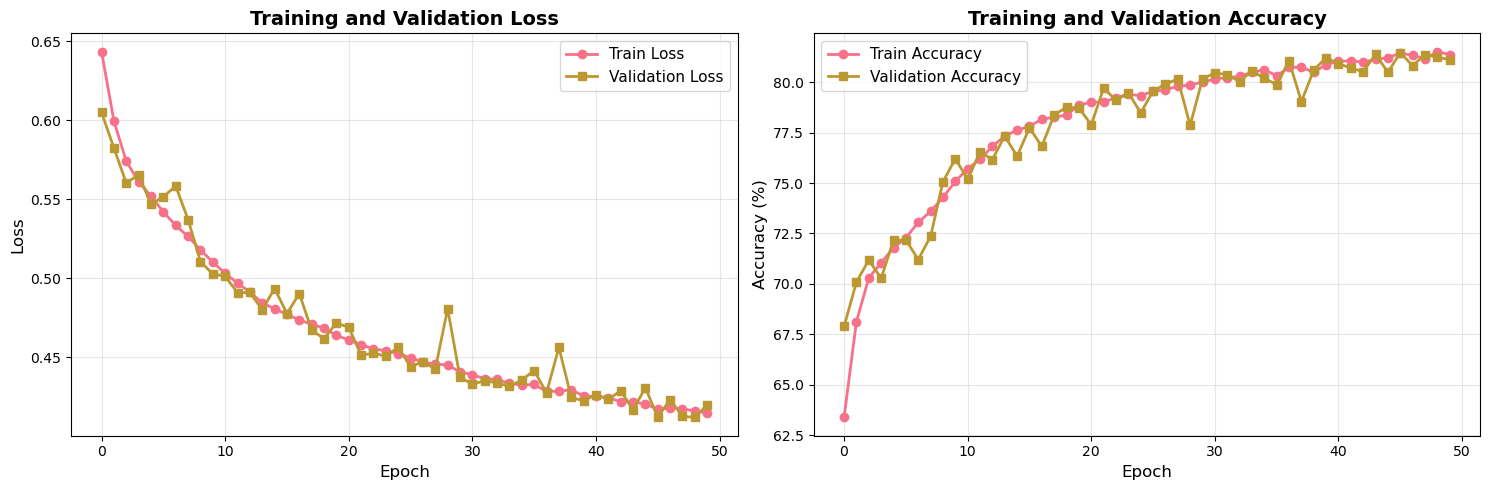


Training Summary:
  Final Train Loss: 0.4148
  Final Train Accuracy: 81.36%
  Final Val Loss: 0.4199
  Final Val Accuracy: 81.11%
  Best Val Accuracy: 81.45% (Epoch 46)


In [8]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation Loss', marker='s', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2)
axes[1].plot(history['val_acc'], label='Validation Accuracy', marker='s', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nTraining Summary:")
print(f"  Final Train Loss: {history['train_loss'][-1]:.4f}")
print(f"  Final Train Accuracy: {history['train_acc'][-1]:.2f}%")
print(f"  Final Val Loss: {history['val_loss'][-1]:.4f}")
print(f"  Final Val Accuracy: {history['val_acc'][-1]:.2f}%")
print(f"  Best Val Accuracy: {best_val_acc:.2f}% (Epoch {best_epoch})")

## 7. Load Best Model & Evaluate

In [9]:
# Load best model
checkpoint = torch.load('checkpoint_epoch/model_best.pt')
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"Validation accuracy: {checkpoint['val_acc']:.2f}%")

Loaded best model from epoch 46
Validation accuracy: 81.45%


In [10]:
# Evaluate on test set
def evaluate_model(model, test_loader, device):
    model.eval()
    all_labels = []
    all_predictions = []
    all_probs = []
    
    with torch.no_grad():
        for data, labels in test_loader:
            data, labels = data.to(device), labels.to(device)
            
            outputs = model(data)
            probs = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    return np.array(all_labels), np.array(all_predictions), np.array(all_probs)

# Get predictions
y_true, y_pred, y_probs = evaluate_model(model, test_loader, device)

print("Test set evaluation completed.")
print(f"Total test samples: {len(y_true)}")

Test set evaluation completed.
Total test samples: 16099


## 8. Evaluation Metrics

In [ ]:
# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("=" * 70)
print("TEST SET PERFORMANCE METRICS")
print("=" * 70)
print(f"Accuracy:  {accuracy*100:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("=" * 70)

# Detailed classification report
print("\nDETAILED CLASSIFICATION REPORT:")
print("-" * 70)
print(classification_report(y_true, y_pred, target_names=['Normal', 'Class 1'], digits=4))

# Per-class metrics
print("\nPER-CLASS METRICS:")
print("-" * 70)
class_names = ['Normal', 'Class 1']
for i in range(2):
    mask = y_true == i
    if mask.sum() > 0:
        class_acc = (y_pred[mask] == i).sum() / mask.sum()
        print(f"{class_names[i]} - Samples: {mask.sum():4d} | Accuracy: {class_acc*100:.2f}%")

TEST SET PERFORMANCE METRICS
Accuracy:  81.51%
Precision: 0.8147
Recall:    0.8151
F1-Score:  0.8146

DETAILED CLASSIFICATION REPORT:
----------------------------------------------------------------------
              precision    recall  f1-score   support

     Class 0     0.8238    0.8520    0.8376      9013
     Class 1     0.8032    0.7681    0.7853      7086

    accuracy                         0.8151     16099
   macro avg     0.8135    0.8101    0.8114     16099
weighted avg     0.8147    0.8151    0.8146     16099


PER-CLASS METRICS:
----------------------------------------------------------------------
Class 0 - Samples: 9013 | Accuracy: 85.20%
Class 1 - Samples: 7086 | Accuracy: 76.81%


## 9. Confusion Matrix

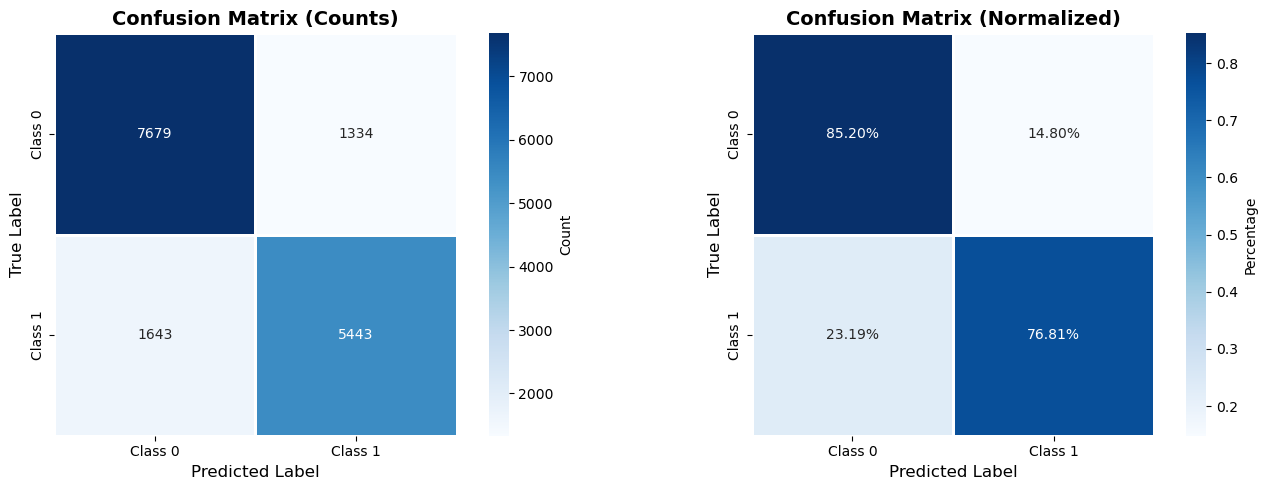


Confusion Matrix Analysis:
----------------------------------------------------------------------
True Negatives (TN):  7679  |  False Positives (FP): 1334
False Negatives (FN): 1643  |  True Positives (TP):  5443

Sensitivity (Recall): 0.7681
Specificity:          0.8520


In [ ]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            cbar_kws={'label': 'Count'}, square=True, linewidths=1,
            annot_kws={'fontsize': 16})
axes[0].set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=14, fontweight='bold')
axes[0].set_title('Confusion Matrix (Counts)', fontsize=16, fontweight='bold')
axes[0].set_xticklabels(['Normal', 'Class 1'], fontsize=13)
axes[0].set_yticklabels(['Normal', 'Class 1'], fontsize=13, rotation=0)
axes[0].tick_params(axis='both', which='major', labelsize=13)

# Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1], 
            cbar_kws={'label': 'Percentage'}, square=True, linewidths=1,
            annot_kws={'fontsize': 16})
axes[1].set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=14, fontweight='bold')
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=16, fontweight='bold')
axes[1].set_xticklabels(['Normal', 'Class 1'], fontsize=13)
axes[1].set_yticklabels(['Normal', 'Class 1'], fontsize=13, rotation=0)
axes[1].tick_params(axis='both', which='major', labelsize=13)

plt.tight_layout()
plt.show()

# Print confusion matrix details
print("\nConfusion Matrix Analysis:")
print("-" * 70)
print(f"True Negatives (TN):  {cm[0, 0]:4d}  |  False Positives (FP): {cm[0, 1]:4d}")
print(f"False Negatives (FN): {cm[1, 0]:4d}  |  True Positives (TP):  {cm[1, 1]:4d}")

if cm.shape[0] == 2:  # Binary classification
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f"\nSensitivity (Recall): {sensitivity:.4f}")
    print(f"Specificity:          {specificity:.4f}")

## 10. SincNet Filter Visualization

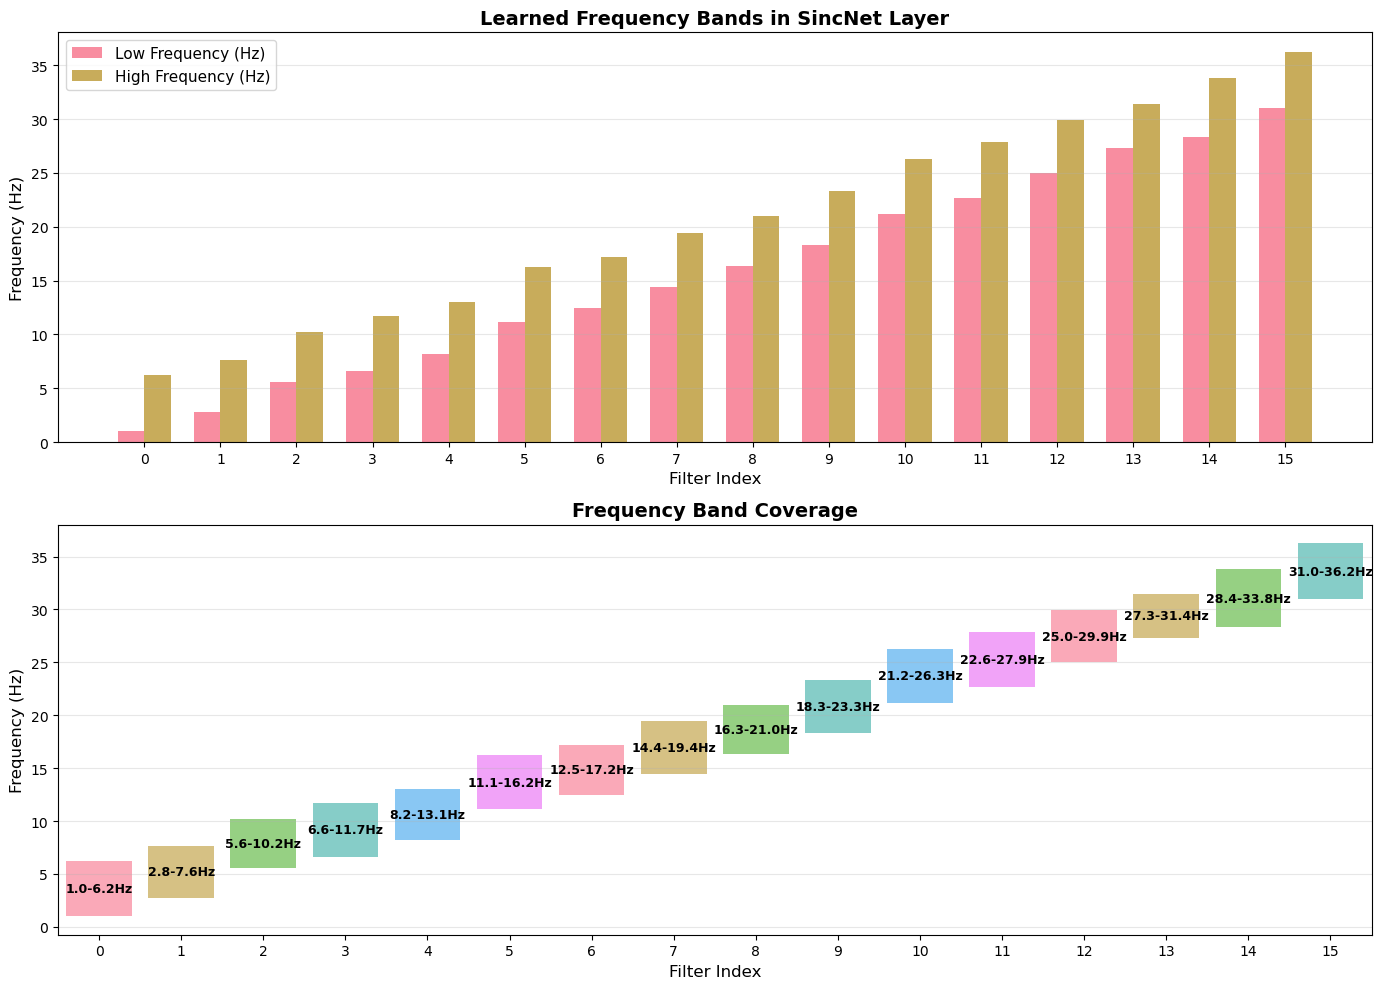


Learned Frequency Bands (Hz):
Filter     Low (Hz)     High (Hz)    Bandwidth (Hz) 
----------------------------------------------------------------------
Filter 0         1.02         6.24            5.22
Filter 1         2.77         7.61            4.84
Filter 2         5.58        10.19            4.62
Filter 3         6.59        11.72            5.13
Filter 4         8.17        13.06            4.89
Filter 5        11.14        16.23            5.09
Filter 6        12.50        17.23            4.73
Filter 7        14.41        19.43            5.02
Filter 8        16.32        20.98            4.66
Filter 9        18.34        23.30            4.96
Filter 10       21.17        26.27            5.10
Filter 11       22.64        27.90            5.26
Filter 12       25.03        29.94            4.90
Filter 13       27.34        31.43            4.08
Filter 14       28.35        33.79            5.44
Filter 15       31.02        36.24            5.22


In [13]:
# Visualize learned frequency bands
sinc_layer = model.sinc

low_hz = sinc_layer.min_freq + torch.abs(sinc_layer.low_hz_).detach().cpu().numpy()
high_hz = low_hz + torch.abs(sinc_layer.band_hz_).detach().cpu().numpy()
high_hz = np.clip(high_hz, sinc_layer.min_freq, sinc_layer.max_freq)

# Create visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Bar plot of frequency bands
x = np.arange(len(low_hz))
width = 0.35

axes[0].bar(x - width/2, low_hz, width, label='Low Frequency (Hz)', alpha=0.8)
axes[0].bar(x + width/2, high_hz, width, label='High Frequency (Hz)', alpha=0.8)
axes[0].set_xlabel('Filter Index', fontsize=12)
axes[0].set_ylabel('Frequency (Hz)', fontsize=12)
axes[0].set_title('Learned Frequency Bands in SincNet Layer', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_xticks(x)

# Frequency band visualization
for i in range(len(low_hz)):
    axes[1].fill_between([i-0.4, i+0.4], [low_hz[i], low_hz[i]], 
                         [high_hz[i], high_hz[i]], alpha=0.6, label=f'Filter {i}')
    axes[1].text(i, (low_hz[i] + high_hz[i])/2, f'{low_hz[i]:.1f}-{high_hz[i]:.1f}Hz', 
                ha='center', va='center', fontsize=9, fontweight='bold')

axes[1].set_xlabel('Filter Index', fontsize=12)
axes[1].set_ylabel('Frequency (Hz)', fontsize=12)
axes[1].set_title('Frequency Band Coverage', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_xlim(-0.5, len(low_hz)-0.5)
axes[1].set_xticks(x)

plt.tight_layout()
plt.show()

# Print learned frequencies
print("\nLearned Frequency Bands (Hz):")
print("=" * 70)
print(f"{'Filter':<10} {'Low (Hz)':<12} {'High (Hz)':<12} {'Bandwidth (Hz)':<15}")
print("-" * 70)
for i in range(len(low_hz)):
    bandwidth = high_hz[i] - low_hz[i]
    print(f"Filter {i:<3} {low_hz[i]:>10.2f}   {high_hz[i]:>10.2f}   {bandwidth:>13.2f}")
print("=" * 70)

## 11. Summary & Save Results

In [14]:
# Save learned frequency bands to CSV
frequency_bands_df = pd.DataFrame({
    'Filter': [f'Filter_{i}' for i in range(len(low_hz))],
    'Low_Hz': low_hz,
    'High_Hz': high_hz,
    'Bandwidth_Hz': high_hz - low_hz
})
frequency_bands_df.to_csv('learned_frequency_bands.csv', index=False)
print("Saved learned frequency bands to 'learned_frequency_bands.csv'")

# Save training history to CSV
history_df = pd.DataFrame(history)
history_df['epoch'] = range(1, len(history_df) + 1)
history_df = history_df[['epoch', 'train_loss', 'train_acc', 'val_loss', 'val_acc']]
history_df.to_csv('training_history.csv', index=False)
print("Saved training history to 'training_history.csv'")

# Create comprehensive results summary
results_summary = {
    'Model': 'SincNet-ECG',
    'Total_Parameters': sum(p.numel() for p in model.parameters()),
    'SincNet_Filters': len(low_hz),
    'Best_Epoch': best_epoch,
    'Best_Val_Acc': best_val_acc,
    'Test_Accuracy': accuracy * 100,
    'Test_Precision': precision,
    'Test_Recall': recall,
    'Test_F1': f1,
    'Train_Samples': len(train_idx),
    'Val_Samples': len(val_idx),
    'Test_Samples': len(test_idx)
}

# Save results summary
results_df = pd.DataFrame([results_summary])
results_df.to_csv('model_results_summary.csv', index=False)
print("Saved model results summary to 'model_results_summary.csv'")

# Print final summary
print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)
print(f"Model: SincNet-ECG with {len(low_hz)} filters")
print(f"Total Parameters: {results_summary['Total_Parameters']:,}")
print(f"Best Validation Accuracy: {best_val_acc:.2f}% (Epoch {best_epoch})")
print(f"Test Set Performance:")
print(f"  - Accuracy:  {accuracy*100:.2f}%")
print(f"  - Precision: {precision:.4f}")
print(f"  - Recall:    {recall:.4f}")
print(f"  - F1-Score:  {f1:.4f}")
print("=" * 70)
print("\n✅ Training and evaluation complete!")

Saved learned frequency bands to 'learned_frequency_bands.csv'
Saved training history to 'training_history.csv'
Saved model results summary to 'model_results_summary.csv'

FINAL SUMMARY
Model: SincNet-ECG with 16 filters
Total Parameters: 2,690
Best Validation Accuracy: 81.45% (Epoch 46)
Test Set Performance:
  - Accuracy:  81.51%
  - Precision: 0.8147
  - Recall:    0.8151
  - F1-Score:  0.8146

✅ Training and evaluation complete!
